In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

In [4]:
image = cv2.imread('fruit basket.jpg', cv2.IMREAD_GRAYSCALE)

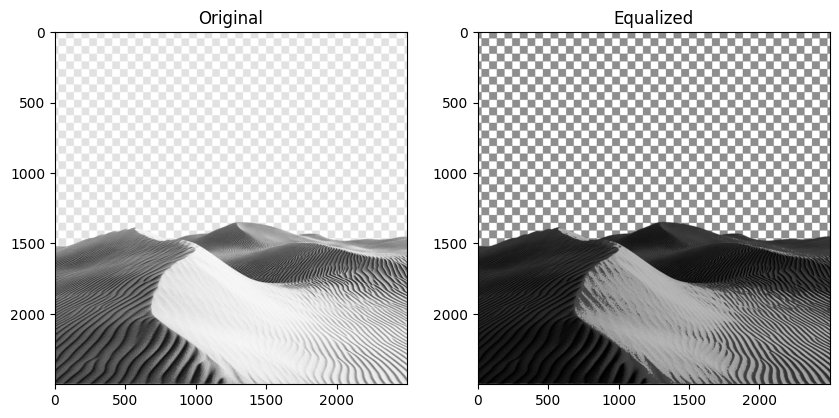

In [5]:
equalized = cv2.equalizeHist(image)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized")

plt.show()

/tmp/ipykernel_310/3764068114.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0,256])
/tmp/ipykernel_310/3764068114.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0,256])


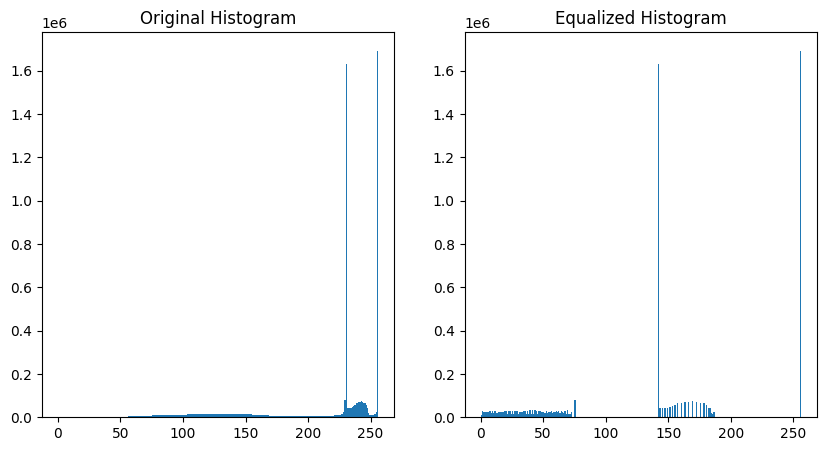

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(image.ravel(), 256, [0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(equalized.ravel(), 256, [0,256])
plt.title("Equalized Histogram")

plt.show()

In [7]:
gaussian_3 = cv2.GaussianBlur(image, (3, 3), 0)
gaussian_5 = cv2.GaussianBlur(image, (5, 5), 0)

In [8]:
def box_filt(n):
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel

In [9]:
def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))

    image_padded = np.pad(image_input,
                          pad_width=((pad_size,pad_size),
                                     (pad_size,pad_size)),
                          mode='symmetric')

    image_box = copy.deepcopy(image_input)
    row, column = image_input.shape

    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size,
                                      j:j + filt_size]
            results_box = box * patch_curr
            image_box[i,j] = np.sum(results_box)

    return image_box

In [10]:
box_kernel = box_filt(5)
box_filtered = apply_filters(image, box_kernel, 5)

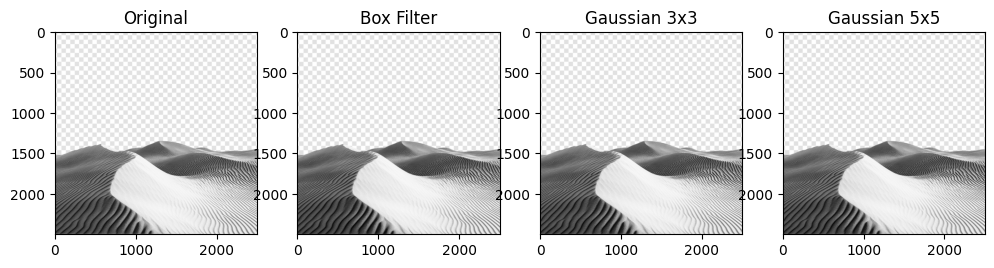

In [11]:
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(box_filtered, cmap='gray')
plt.title("Box Filter")

plt.subplot(1,4,3)
plt.imshow(gaussian_3, cmap='gray')
plt.title("Gaussian 3x3")

plt.subplot(1,4,4)
plt.imshow(gaussian_5, cmap='gray')
plt.title("Gaussian 5x5")

plt.show()

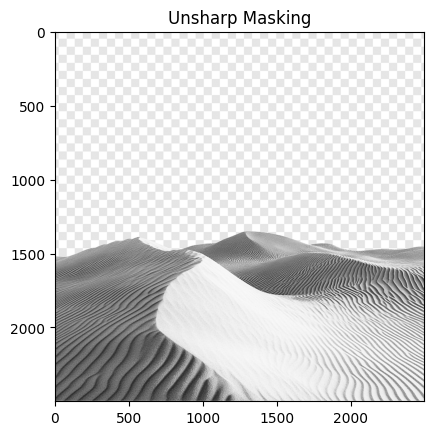

In [12]:
blurred = cv2.GaussianBlur(image, (9, 9), 10)

unsharp_image = cv2.addWeighted(image, 1.5,
                                blurred, -0.5, 0)

plt.imshow(unsharp_image, cmap='gray')
plt.title('Unsharp Masking')
plt.show()

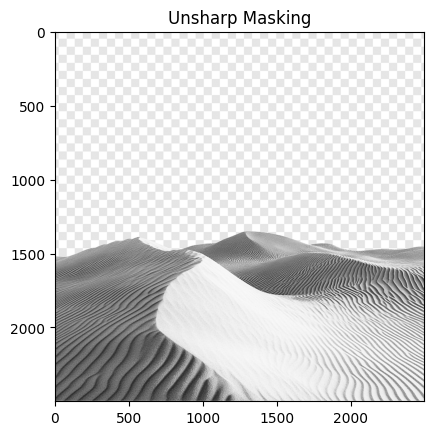

In [13]:
blurred = cv2.GaussianBlur(image, (9, 9), 10)

unsharp_image = cv2.addWeighted(image, 1.5,
                                blurred, -0.5, 0)

plt.imshow(unsharp_image, cmap='gray')
plt.title('Unsharp Masking')
plt.show()

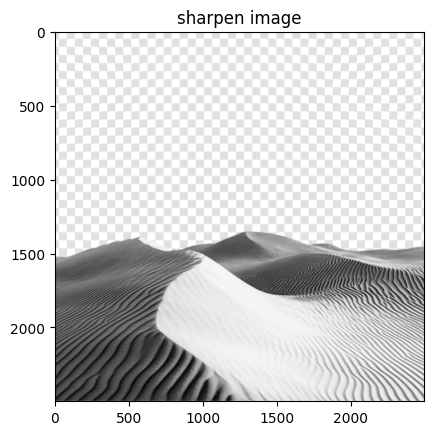

In [18]:
filt_size = 5
k = -1

image_input = cv2.imread('fruit basket.jpg', 0).astype('float32')/255
box = box_filt(filt_size)

image_blur = apply_filters(image_input, box, filt_size)
image_diff = image_input - image_blur
image_sharp = image_input + k*image_diff

plt.imshow(image_sharp, cmap='gray')
plt.title('sharpen image')
plt.show()

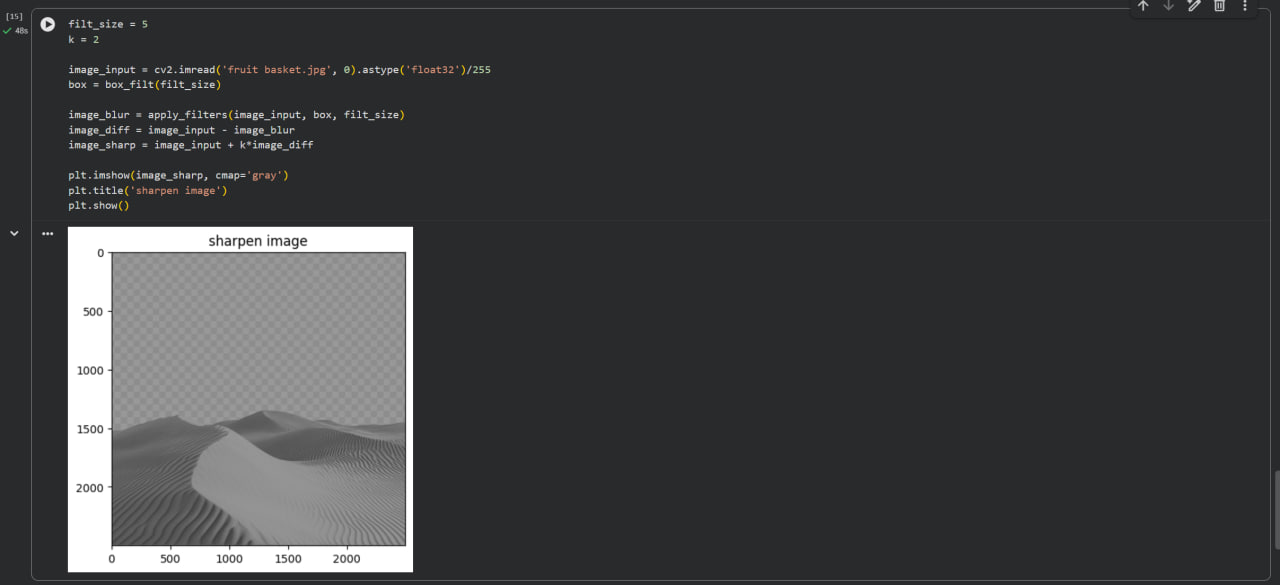

**bold text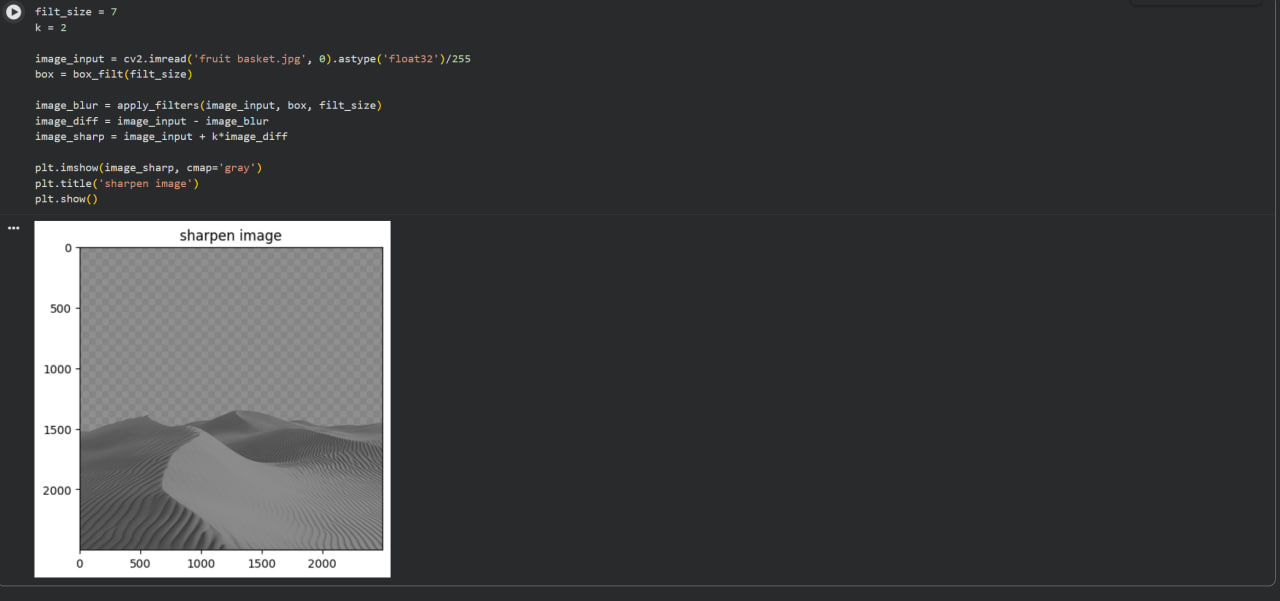**

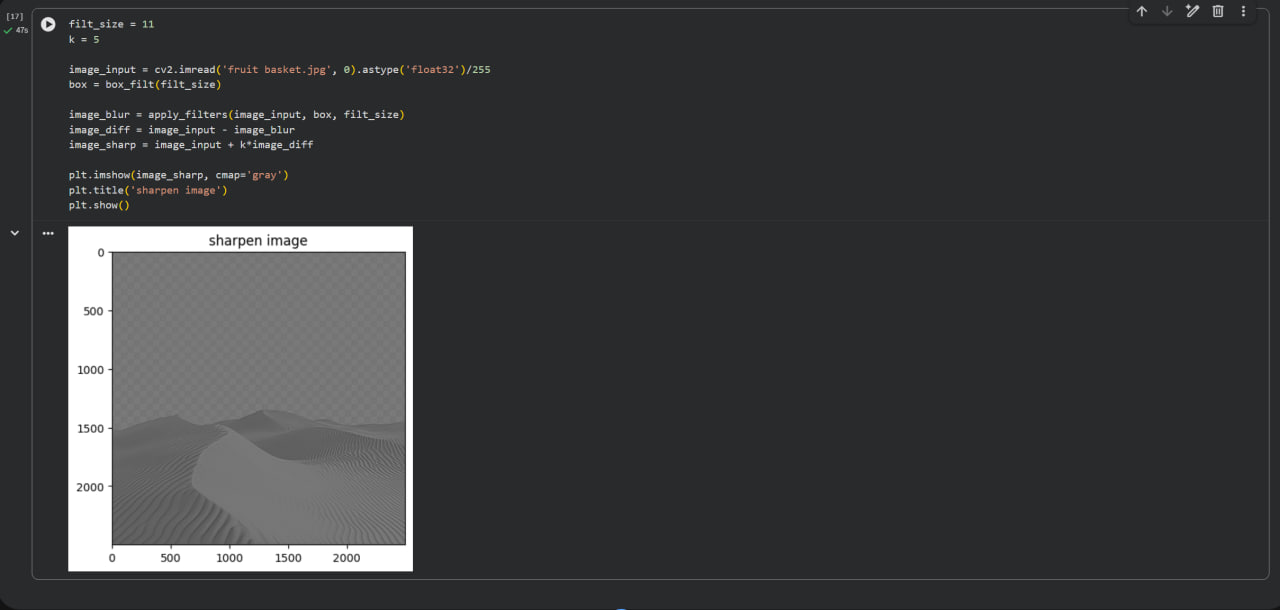

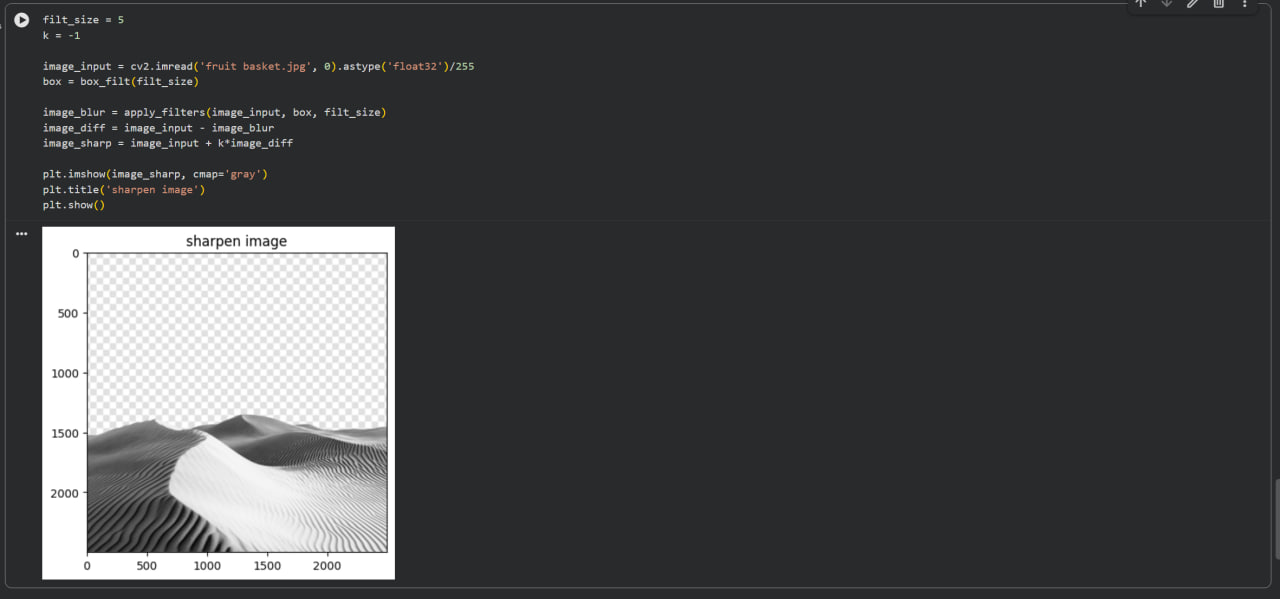

Task 1 – Histogram Equalization

Histogram equalization improved image contrast by redistributing pixel intensity values. Dark areas became more visible and overall contrast increased.

Task 2 – Gaussian vs Box Filter

Increasing kernel size increased blur.
The box filter performs uniform averaging, while the Gaussian filter applies weighted averaging.
Gaussian smoothing produced more natural results.

Task 3 – Unsharp Masking

Sharpening was performed using:

image_sharp = image + k(image − image_blur)

Positive k enhanced edges.
Large k introduced noise.
Negative k caused additional smoothing.

Task 4 – Parameter Analysis

Tested values:

filt_size = 5, 7, 11

k = 2, 5, -1

Observations:

Larger filt_size → stronger blur.

k > 0 → increased sharpness.

Large k → edge over-enhancement.

k < 0 → smoothing effect.

Conclusion

Image enhancement strongly depends on kernel size and sharpening coefficient. Proper parameter selection is necessary to balance blur and sharpness.